#### Notebook Setup

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/DAT255/voice-command-assistant")
os.environ["HF_HOME"] = str(PROJECT_ROOT/"data/cache/hf_home")
os.environ["HF_DATASETS_CACHE"] = str(PROJECT_ROOT/"data/cache/hf_datasets")
os.environ["TRANSFORMERS_CACHE"] = str(PROJECT_ROOT/"data/cache/transformers")

print("PROJECT_ROOT:", PROJECT_ROOT)

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/DAT255/voice-command-assistant


# Notebook 07 — Architecture Comparison

## Spectrogram CNN vs Raw Waveform Conv1D

This notebook compares two input representations for audio classification:

| Model | Input |
|------|------|
| Spectrogram CNN | Mel-spectrogram |
| Raw Conv1D | Raw waveform |

Both models are trained on the same dataset and evaluated using accuracy, macro F1, confusion matrix, and latency.

## 1. Setup + Dataset (Raw Waveform)

#### Imports + device

In [2]:
import torch
import numpy as np
import pandas as pd
import librosa

from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device: cuda
GPU: NVIDIA A100-SXM4-80GB


#### Load index.csv

In [3]:
index_path = PROJECT_ROOT/"data/processed/index.csv"
assert index_path.exists()

index_df = pd.read_csv(index_path)

print("index_df shape:", index_df.shape)
index_df.head()

index_df shape: (99720, 8)


,file,split,speaker_id,original_label_id,original_label_name,target_label,target_id,is_unknown
0,backward/2356b88d_nohash_0.wav,train,2356b88d,30,backward,unknown,4,True
1,backward/3291330e_nohash_3.wav,train,3291330e,30,backward,unknown,4,True
2,backward/b91b718c_nohash_3.wav,train,b91b718c,30,backward,unknown,4,True
3,backward/85851131_nohash_1.wav,train,85851131,30,backward,unknown,4,True
4,backward/244cc3a5_nohash_0.wav,train,244cc3a5,30,backward,unknown,4,True


#### 5-class filtering

In [4]:
FIVE_CLASS = ["up", "down", "left", "right", "unknown"]

class_names_5 = FIVE_CLASS
label_to_5id = {c:i for i,c in enumerate(class_names_5)}

df5_train = index_df[(index_df["split"]=="train") & (index_df["target_label"].isin(FIVE_CLASS))]
df5_val   = index_df[(index_df["split"]=="validation") & (index_df["target_label"].isin(FIVE_CLASS))]
df5_test  = index_df[(index_df["split"]=="test") & (index_df["target_label"].isin(FIVE_CLASS))]

print("Train:", len(df5_train))
print("Val:", len(df5_val))
print("Test:", len(df5_test))

Train: 84848
Val: 9982
Test: 4890


#### Last Speech Commands dataset

In [5]:
ds = load_dataset("google/speech_commands", "v0.02")

file_to_idx = {}

for split in ["train","validation","test"]:
    file_to_idx[split] = {
        ds[split][i]["file"]: i for i in range(len(ds[split]))
    }

print("Lookup built:", {k: len(v) for k,v in file_to_idx.items()})

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Using the latest cached version of the dataset since google/speech_commands couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'v0.02' at /content/drive/MyDrive/DAT255/voice-command-assistant/data/cache/hf_datasets/google___speech_commands/v0.02/0.2.0/ba3d9a6cf49aa1313c51abe16b59203451482ccb9fee6d23c94fecabf3e206da (last modified on Wed Feb 25 14:03:30 2026).


Lookup built: {'train': 84848, 'validation': 9982, 'test': 4890}


#### Raw waveform preprocessing

In [6]:
SR = 16000
N_SAMPLES = 16000

def pad_or_trim(x, n_samples=N_SAMPLES):

    if len(x) < n_samples:
        x = np.pad(x, (0, n_samples-len(x)))
    else:
        x = x[:n_samples]

    return x.astype(np.float32)

#### Raw waveform Dataset

In [7]:
class RawSpeechCommandsDataset(Dataset):

    def __init__(self, df, split_name):

        self.df = df.reset_index(drop=True)
        self.split = split_name

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        f = row["file"]
        hf_idx = file_to_idx[self.split][f]

        ex = ds[self.split][hf_idx]

        audio = ex["audio"]["array"]
        sr = ex["audio"]["sampling_rate"]

        if sr != SR:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=SR)

        audio = pad_or_trim(audio)

        X = torch.from_numpy(audio).unsqueeze(0).float()

        y = label_to_5id[row["target_label"]]

        return X, y

#### DataLoaders

In [8]:
train_ds_raw = RawSpeechCommandsDataset(df5_train, "train")
val_ds_raw   = RawSpeechCommandsDataset(df5_val, "validation")
test_ds_raw  = RawSpeechCommandsDataset(df5_test, "test")

train_loader_raw = DataLoader(train_ds_raw, batch_size=64, shuffle=True, num_workers=0)
val_loader_raw   = DataLoader(val_ds_raw, batch_size=64, shuffle=False, num_workers=0)
test_loader_raw  = DataLoader(test_ds_raw, batch_size=64, shuffle=False, num_workers=0)

Xb, yb = next(iter(train_loader_raw))

print("Batch shapes:", Xb.shape, yb.shape)

Batch shapes: torch.Size([64, 1, 16000]) torch.Size([64])


## 2. Raw Waveform Conv1D Model

#### Raw Conv1D architecture

In [9]:
import torch.nn as nn

class RawWaveformConvNet(nn.Module):

    def __init__(self, n_classes=5):
        super().__init__()

        self.net = nn.Sequential(

            nn.Conv1d(1, 16, kernel_size=80, stride=4, padding=38),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),

            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.net(x)

#### Initialize model

In [10]:
model_raw = RawWaveformConvNet(n_classes=5).to(device)

n_params = sum(p.numel() for p in model_raw.parameters() if p.requires_grad)

print("Trainable params:", n_params)

Trainable params: 9621


#### Training config

In [11]:
LR = 1e-3
EPOCHS = 10

optimizer_raw = torch.optim.Adam(model_raw.parameters(), lr=LR)
criterion_raw = nn.CrossEntropyLoss()

#### Training loop

In [12]:
from sklearn.metrics import accuracy_score

best_val_acc_raw = 0
best_state_raw = None
best_epoch_raw = 0

for epoch in range(EPOCHS):

    model_raw.train()

    train_preds = []
    train_targets = []

    for X, y in train_loader_raw:

        X = X.to(device)
        y = y.to(device)

        optimizer_raw.zero_grad()

        logits = model_raw(X)

        loss = criterion_raw(logits, y)

        loss.backward()

        optimizer_raw.step()

        preds = logits.argmax(dim=1)

        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(y.cpu().numpy())

    train_acc = accuracy_score(train_targets, train_preds)

    model_raw.eval()

    val_preds = []
    val_targets = []

    with torch.no_grad():

        for X, y in val_loader_raw:

            X = X.to(device)
            y = y.to(device)

            logits = model_raw(X)

            preds = logits.argmax(dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(y.cpu().numpy())

    val_acc = accuracy_score(val_targets, val_preds)

    if val_acc > best_val_acc_raw:

        best_val_acc_raw = val_acc
        best_epoch_raw = epoch

        best_state_raw = {
            k: v.cpu().clone() for k, v in model_raw.state_dict().items()
        }

    print(f"Epoch {epoch+1}/{EPOCHS} | train_acc {train_acc:.4f} | val_acc {val_acc:.4f}")

print("Best val acc:", best_val_acc_raw, "epoch:", best_epoch_raw+1)

Epoch 1/10 | train_acc 0.8533 | val_acc 0.8517
Epoch 2/10 | train_acc 0.8601 | val_acc 0.8577
Epoch 3/10 | train_acc 0.8619 | val_acc 0.8547
Epoch 4/10 | train_acc 0.8633 | val_acc 0.8624
Epoch 5/10 | train_acc 0.8650 | val_acc 0.8650
Epoch 6/10 | train_acc 0.8668 | val_acc 0.8605
Epoch 7/10 | train_acc 0.8695 | val_acc 0.8641
Epoch 8/10 | train_acc 0.8721 | val_acc 0.8635
Epoch 9/10 | train_acc 0.8748 | val_acc 0.8763
Epoch 10/10 | train_acc 0.8796 | val_acc 0.8695
Best val acc: 0.8762772991384492 epoch: 9


## 3. Evaluation + latency + comparison table

#### Load best raw model + evaluate

In [13]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

model_raw.load_state_dict(best_state_raw)
model_raw.to(device)
model_raw.eval()

def evaluate_raw(model, loader):
    model.eval()
    preds = []
    targets = []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.to(device)

            logits = model(X)
            p = logits.argmax(dim=1)

            preds.extend(p.cpu().numpy())
            targets.extend(y.cpu().numpy())

    acc = accuracy_score(targets, preds)
    macro_f1 = f1_score(targets, preds, average="macro")
    return acc, macro_f1, preds, targets

val_acc_raw, val_f1_raw, val_preds_raw, val_targets_raw = evaluate_raw(model_raw, val_loader_raw)
test_acc_raw, test_f1_raw, test_preds_raw, test_targets_raw = evaluate_raw(model_raw, test_loader_raw)

print("RAW VAL  acc:", val_acc_raw)
print("RAW VAL  macro F1:", val_f1_raw)
print("RAW TEST acc:", test_acc_raw)
print("RAW TEST macro F1:", test_f1_raw)

RAW VAL  acc: 0.8762772991384492
RAW VAL  macro F1: 0.4973883875846776
RAW TEST acc: 0.7092024539877301
RAW TEST macro F1: 0.4519248372959945


#### Confusion matrix + save figure

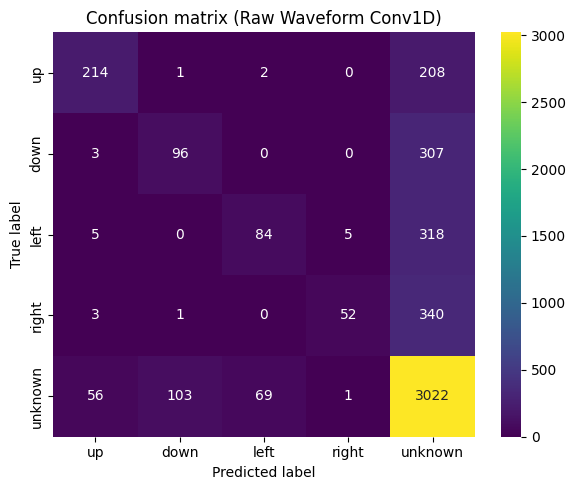

Saved figure: /content/drive/MyDrive/DAT255/voice-command-assistant/results/figures/confusion_matrix_raw_waveform_conv1d.png


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_raw = confusion_matrix(test_targets_raw, test_preds_raw)

fig_dir = PROJECT_ROOT/"results/figures"
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_raw,
    annot=True,
    fmt="d",
    xticklabels=class_names_5,
    yticklabels=class_names_5,
    cmap="viridis"
)
plt.title("Confusion matrix (Raw Waveform Conv1D)")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()

cm_raw_path = fig_dir/"confusion_matrix_raw_waveform_conv1d.png"
plt.savefig(cm_raw_path, dpi=200)
plt.show()

print("Saved figure:", cm_raw_path)

#### Latency benchmark for raw model

In [15]:
import time
import os
import pandas as pd

def benchmark_raw(model, sample_X, n_warmup=30, n_iters=200, device="cuda"):
    model = model.to(device)
    model.eval()
    X = sample_X.to(device)

    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(X)

        if device == "cuda":
            torch.cuda.synchronize()

        t0 = time.perf_counter()
        for _ in range(n_iters):
            _ = model(X)
        if device == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()

    return (t1 - t0) * 1000.0 / n_iters

X_sample_raw, y_sample_raw = next(iter(test_loader_raw))
sample_raw = X_sample_raw[:1]

raw_gpu_ms = None
if torch.cuda.is_available():
    raw_gpu_ms = benchmark_raw(model_raw, sample_raw, device="cuda")
    print("RAW GPU latency (ms/sample):", raw_gpu_ms)

raw_cpu_ms = benchmark_raw(model_raw, sample_raw, device="cpu")
print("RAW CPU latency (ms/sample):", raw_cpu_ms)

RAW GPU latency (ms/sample): 0.6292043099983857
RAW CPU latency (ms/sample): 0.8361432849960693


#### Save raw metrics

In [16]:
import time

metrics_dir = PROJECT_ROOT/"results/metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

run_name_raw = f"raw_waveform_conv1d_{int(time.time())}"

metrics_raw = pd.DataFrame([{
    "run_name": run_name_raw,
    "n_params": int(sum(p.numel() for p in model_raw.parameters() if p.requires_grad)),
    "best_val_acc": float(best_val_acc_raw),
    "best_epoch": int(best_epoch_raw + 1),
    "val_acc": float(val_acc_raw),
    "val_macro_f1": float(val_f1_raw),
    "test_acc": float(test_acc_raw),
    "test_macro_f1": float(test_f1_raw),
    "gpu_latency_ms": None if raw_gpu_ms is None else float(raw_gpu_ms),
    "cpu_latency_ms": float(raw_cpu_ms),
}])

metrics_raw_path = metrics_dir/f"{run_name_raw}_metrics.csv"
metrics_raw.to_csv(metrics_raw_path, index=False)

print("Saved metrics:", metrics_raw_path)
metrics_raw

Saved metrics: /content/drive/MyDrive/DAT255/voice-command-assistant/results/metrics/raw_waveform_conv1d_1772920921_metrics.csv


,run_name,n_params,best_val_acc,best_epoch,val_acc,val_macro_f1,test_acc,test_macro_f1,gpu_latency_ms,cpu_latency_ms
0,raw_waveform_conv1d_1772920921,9621,0.876277,9,0.876277,0.497388,0.709202,0.451925,0.629204,0.836143


#### Comparison table vs best spectrogram model

In [17]:
comparison_df = pd.DataFrame([
    {
        "model": "Spectrogram CNN (best E2)",
        "input": "Mel-spectrogram",
        "params": 23845,
        "test_acc": 0.784,
        "test_macro_f1": 0.707,
        "gpu_latency_ms": 0.559,
        "cpu_latency_ms": 1.203,
    },
    {
        "model": "Raw Waveform Conv1D",
        "input": "Raw waveform",
        "params": int(sum(p.numel() for p in model_raw.parameters() if p.requires_grad)),
        "test_acc": float(test_acc_raw),
        "test_macro_f1": float(test_f1_raw),
        "gpu_latency_ms": None if raw_gpu_ms is None else float(raw_gpu_ms),
        "cpu_latency_ms": float(raw_cpu_ms),
    }
])

comparison_path = metrics_dir/"architecture_comparison_table.csv"
comparison_df.to_csv(comparison_path, index=False)

print("Saved comparison table:", comparison_path)
comparison_df

Saved comparison table: /content/drive/MyDrive/DAT255/voice-command-assistant/results/metrics/architecture_comparison_table.csv


,model,input,params,test_acc,test_macro_f1,gpu_latency_ms,cpu_latency_ms
0,Spectrogram CNN (best E2),Mel-spectrogram,23845,0.784000,0.707000,0.559000,1.203000
1,Raw Waveform Conv1D,Raw waveform,9621,0.709202,0.451925,0.629204,0.836143
